In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df4 = pd.read_csv(r'E:\Gen AI\AQI_Analysis\Dataset\station_hour.csv')

C:\Users\DELL\AppData\Local\Temp\ipykernel_22860\2012948562.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df4 = pd.read_csv(r'E:\Gen AI\AQI_Analysis\Dataset\station_hour.csv')


In [3]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   StationId   object 
 1   Datetime    object 
 2   PM2.5       float64
 3   PM10        float64
 4   NO          float64
 5   NO2         float64
 6   NOx         float64
 7   NH3         float64
 8   CO          float64
 9   SO2         float64
 10  O3          float64
 11  Benzene     float64
 12  Toluene     float64
 13  Xylene      float64
 14  AQI         float64
 15  AQI_Bucket  object 
dtypes: float64(13), object(3)
memory usage: 316.1+ MB


In [4]:
df4.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,1.941394e+06,1.469831e+06,2.035372e+06,2.060110e+06,2.098275e+06,1.352465e+06,2.089781e+06,1.846346e+06,1.863110e+06,1.727504e+06,1.546717e+06,513979.000000,2.018893e+06
mean,8.086481e+01,1.584839e+02,2.278825e+01,3.523689e+01,4.055115e+01,2.870856e+01,1.502366e+00,1.211602e+01,3.806408e+01,3.305493e+00,1.490266e+01,2.448881,1.801730e+02
std,8.947618e+01,1.397883e+02,4.846146e+01,3.497508e+01,5.590894e+01,2.753244e+01,6.292445e+00,1.467385e+01,4.710653e+01,1.214053e+01,3.329729e+01,8.973470,1.404095e+02
min,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,0.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,0.000000e+00,0.000000,5.000000e+00
25%,2.816000e+01,6.400000e+01,3.050000e+00,1.310000e+01,1.135000e+01,1.123000e+01,4.100000e-01,4.250000e+00,1.102000e+01,8.000000e-02,3.400000e-01,0.000000,8.400000e+01
50%,5.259000e+01,1.162500e+02,7.150000e+00,2.479000e+01,2.286000e+01,2.235000e+01,8.000000e-01,8.250000e+00,2.475000e+01,9.600000e-01,3.400000e+00,0.200000,1.310000e+02
75%,9.774000e+01,2.040000e+02,1.858000e+01,4.548000e+01,4.570000e+01,3.778000e+01,1.380000e+00,1.453000e+01,4.953000e+01,3.230000e+00,1.510000e+01,1.830000,2.590000e+02
max,1.000000e+03,1.000000e+03,5.000000e+02,4.999900e+02,5.000000e+02,4.999700e+02,4.985700e+02,1.999600e+02,9.970000e+02,4.980700e+02,4.999900e+02,499.990000,3.133000e+03


In [5]:
df4.sample(5)

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
2231613,TN001,2018-02-12 23:00:00,46.39,NaN,9.08,20.34,16.58,NaN,1.40,7.13,6.25,0.00,0.0,NaN,78.0,Satisfactory
727568,DL020,2019-10-24 14:00:00,144.50,351.5,7.37,36.35,25.35,44.10,1.45,9.62,67.68,9.03,136.1,NaN,600.0,Severe
530717,DL013,2020-02-12 09:00:00,208.60,NaN,NaN,NaN,NaN,NaN,1.02,31.82,NaN,NaN,NaN,NaN,313.0,Very Poor
2334283,TN004,2017-10-19 21:00:00,32.41,NaN,3.88,46.88,25.13,NaN,1.13,5.14,23.61,0.00,0.0,NaN,NaN,NaN
1839855,MP001,2020-01-17 02:00:00,82.25,120.5,1.25,21.35,12.38,23.55,0.72,26.95,40.48,NaN,NaN,NaN,304.0,Very Poor


### Observation
This is a station-level hourly AQI table, so it is more detailed than the day-level files. That also means it can be large and noisy, so cleaning matters before comparing hourly patterns.


In [6]:
df4.isnull().sum()

StationId           0
Datetime            0
PM2.5          647689
PM10          1119252
NO             553711
NO2            528973
NOx            490808
NH3           1236618
CO             499302
SO2            742737
O3             725973
Benzene        861579
Toluene       1042366
Xylene        2075104
AQI            570190
AQI_Bucket     570190
dtype: int64

In [7]:
df4.isnull().mean()*100

StationId      0.000000
Datetime       0.000000
PM2.5         25.016154
PM10          43.229669
NO            21.386375
NO2           20.430902
NOx           18.956828
NH3           47.762779
CO            19.284897
SO2           28.687261
O3            28.039773
Benzene       33.277380
Toluene       40.260046
Xylene        80.148222
AQI           22.022855
AQI_Bucket    22.022855
dtype: float64

### Observation
`Xylene` has very high missing values here too, so dropping it is a reasonable step. `PM10`, `NH3`, and some other fields also have many missing values, so not every hourly row is complete.


In [8]:
df4 = df4.drop('Xylene', axis=1)

In [9]:
df4 = df4.dropna(subset=df4.columns.difference(['StationId', 'Datetime']), how='all')

### Observation
After dropping `Xylene` and removing nearly empty rows, the data becomes easier to use for hourly analysis. This keeps the useful station-hour records.


## Univariate Analysis

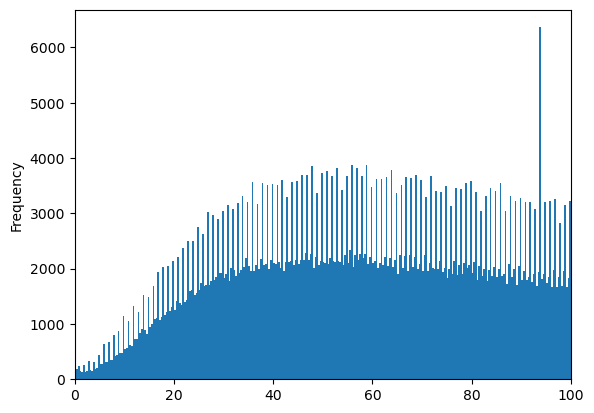

In [10]:
df4['PM10'].dropna().plot(kind='hist', bins=3000)
plt.xlim(0, 100)
plt.show()

### Observation
Most PM10 values are packed in the lower range on this chart, but some values go much higher. So PM10 is not evenly spread.


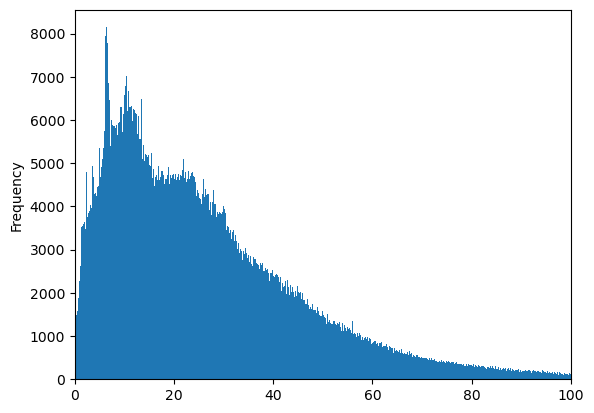

In [11]:
df4['NH3'].dropna().plot(kind='hist', bins=3000)
plt.xlim(0, 100)
plt.show()

### Observation
NH3 also stays mostly in a lower range, but the spread is not balanced. A smaller number of hours show much higher values.


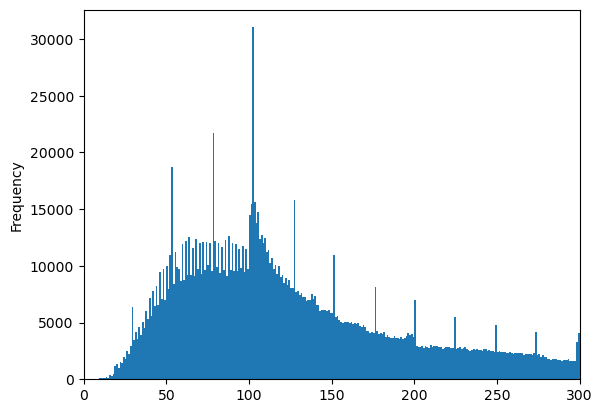

In [12]:
df4['AQI'].dropna().plot(kind='hist', bins=3000)
plt.xlim(0, 300)
plt.show()

### Observation
Most AQI values are in the lower to middle range, but there are some much higher hours too. So AQI is skewed here as well.


## Hourly Analysis

In [13]:
df4['Datetime'] = pd.to_datetime(df4['Datetime'])
df4['Hour'] = df4['Datetime'].dt.hour

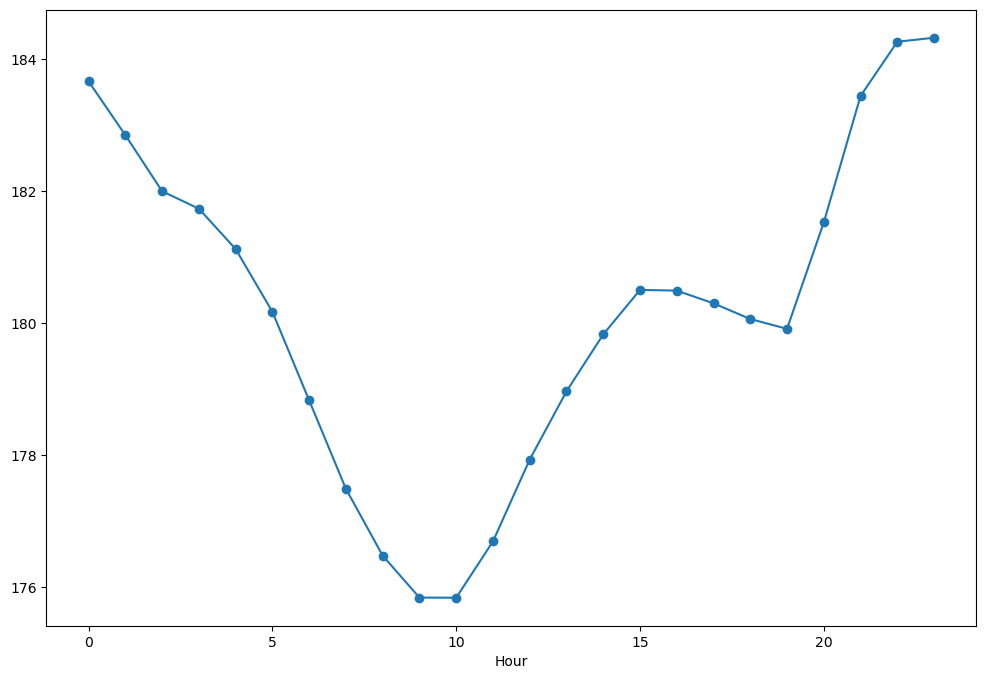

In [14]:
hourly_aqi = df4.groupby('Hour')['AQI'].mean()

plt.figure(figsize=(12, 8))
hourly_aqi.plot(kind='line', marker='o')
plt.show()

### Observation
This plot shows how average AQI changes through the day. It helps show whether some hours are usually cleaner or more polluted than others.


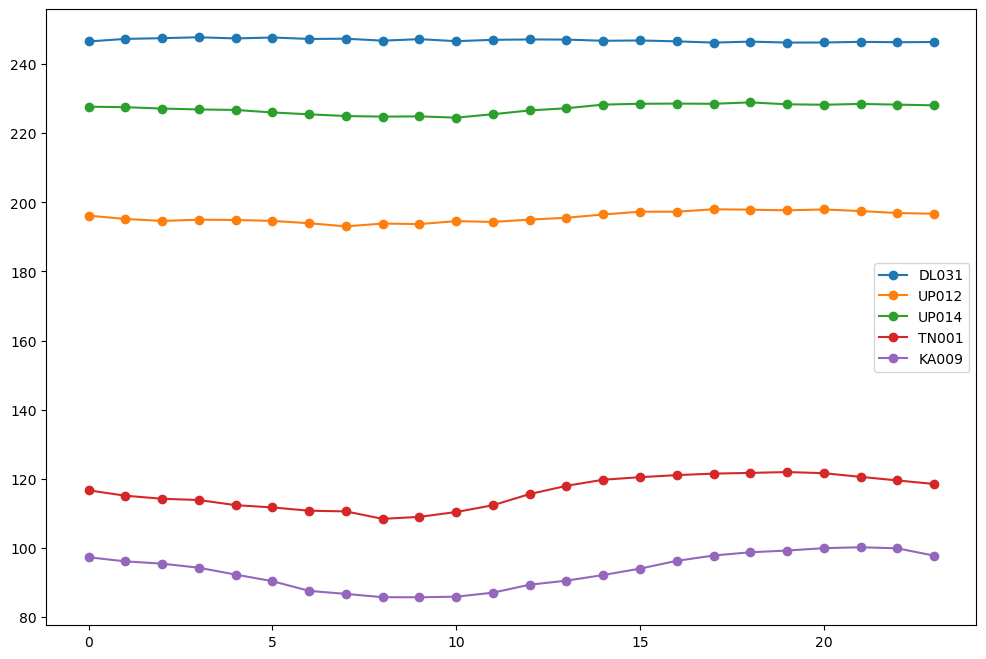

In [15]:
top_stations = df4[df4['AQI'].notna()]['StationId'].value_counts().head(5).index

plt.figure(figsize=(12, 8))
for station in top_stations:
    station_data = df4[df4['StationId'] == station]
    hourly_station = station_data.groupby('Hour')['AQI'].mean()
    plt.plot(hourly_station.index, hourly_station.values, marker='o', label=station)

plt.legend()
plt.show()

### Observation
This added plot compares hourly AQI for the busiest stations in the data. It helps show whether the same day-night pattern appears across different stations.


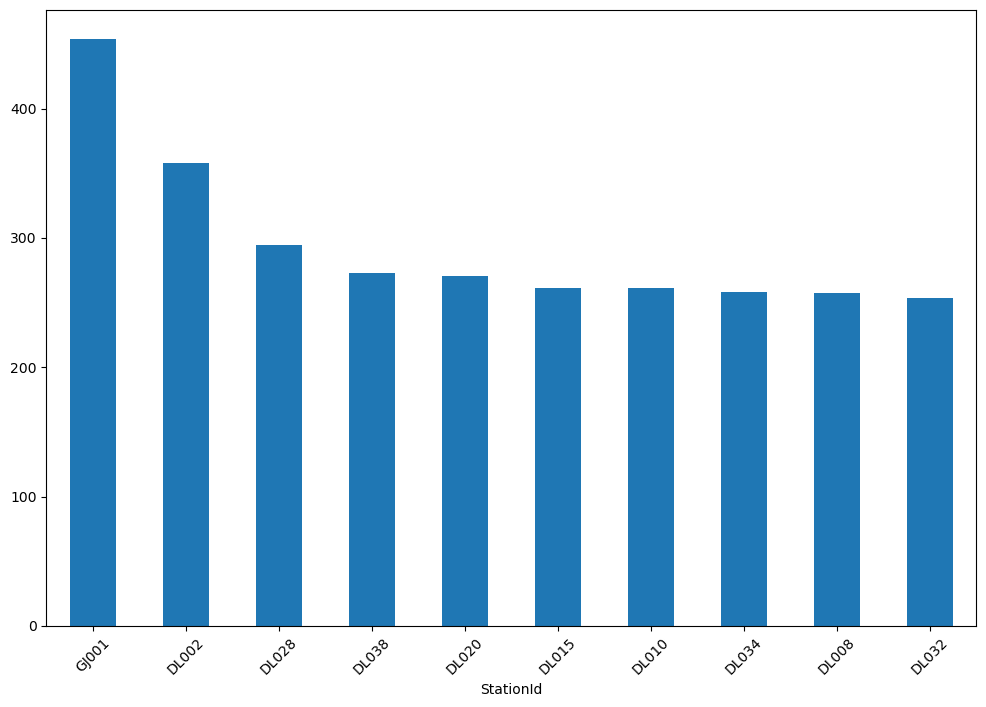

In [16]:
top_station_aqi = df4.groupby('StationId')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
top_station_aqi.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

### Observation
Average AQI is not the same across stations. Some stations stay much more polluted than others even in the hourly data.


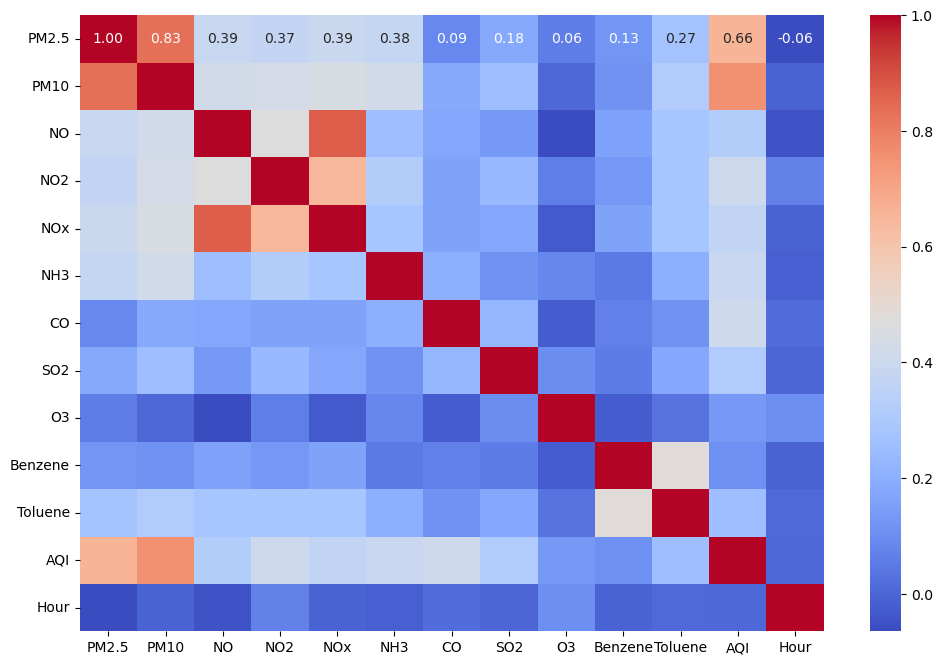

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df4.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

### Observation
The heatmap shows which pollution measures move together. Stronger values mean a stronger relationship.


### Hypothesis Testing
We can test whether AQI really changes by hour, or if the hourly pattern may just be random.


In [18]:
from scipy.stats import kruskal

hour_groups = [group['AQI'].dropna() for _, group in df4.groupby('Hour') if group['AQI'].dropna().shape[0] > 0]
stat, p_value = kruskal(*hour_groups)
print('Kruskal-Wallis statistic:', stat)
print('p-value:', p_value)

if p_value < 0.05:
    print('Conclusion: AQI changes by hour in a meaningful way.')
else:
    print('Conclusion: The hourly difference may be due to random variation.')

Kruskal-Wallis statistic: 1588.840072307283
p-value: 0.0
Conclusion: AQI changes by hour in a meaningful way.


### Observation
If the p-value is below 0.05, we can say the hourly AQI pattern is real in this data. Kruskal-Wallis is a better choice here because AQI is usually skewed.


## Final Conclusion
`Xylene` was removed because too many values were missing.

PM10, NH3, and AQI all show uneven spread, with most values lower and some much higher hours standing out.

The hourly AQI plots help show how air quality changes through the day, both overall and for the busiest stations.

Some stations have much higher average AQI than others, so station-level differences matter a lot in this file.

The hypothesis test is added for hourly AQI because that is the main pattern this notebook is trying to study.
